In [19]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [20]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/amd/amd_data.csv')

In [21]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-03-31,3.050000,1177.0,-416.0,9052.0,9215.0,-163.0,-3.23,0.15
1,1,2009-06-30,3.870000,1184.0,-330.0,8683.0,9148.0,-465.0,-3.98,0.16
2,2,2009-09-30,5.660000,1396.0,-128.0,8747.0,9316.0,-569.0,-3.13,0.12
3,3,2009-12-31,9.680000,1646.0,1178.0,9078.0,8430.0,648.0,0.11,0.11
4,4,2010-03-31,9.270000,1574.0,257.0,5232.0,4436.0,796.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
61,61,2024-06-30,162.210007,5835.0,265.0,67886.0,11348.0,56538.0,3.04,5.33
62,62,2024-09-30,164.080002,6819.0,771.0,69636.0,12651.0,56985.0,2.72,4.83
63,63,2024-12-31,120.790001,7658.0,482.0,69226.0,11658.0,57568.0,2.53,4.33
64,64,2025-03-31,102.739998,7438.0,709.0,71550.0,13669.0,57881.0,1.99,4.33


In [22]:
# create column assets_liabilities_ratio
data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop columns total_assets_musd total_liabilities_musd and other unnecessary columns
data = data.drop(columns=['total_assets_musd', 'total_liabilities_musd', 'Unnamed: 0'])

In [23]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

data[40:]

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-03-31,25.520000,1272.0,16.0,1.568883,1788.0,1.93,2.42
41,2019-06-30,30.370001,1531.0,35.0,1.593877,1901.0,2.24,2.40
42,2019-09-30,28.990000,1801.0,120.0,1.707182,2176.0,2.80,1.83
43,2019-12-31,45.860001,2127.0,170.0,1.883162,2827.0,3.35,1.55
44,2020-03-31,45.480000,1786.0,162.0,2.074284,3037.0,1.28,0.05
45,2020-06-30,52.610001,1932.0,157.0,2.008237,3305.0,-7.50,0.09
46,2020-09-30,81.989998,2801.0,390.0,2.225285,3867.0,-1.41,0.09
47,2020-12-31,91.709999,3244.0,1781.0,2.867840,5837.0,-1.02,0.09
48,2021-03-31,78.500000,3445.0,555.0,2.814286,6477.0,1.76,0.07
49,2021-06-30,93.930000,3850.0,710.0,2.948428,7065.0,12.24,0.10


In [24]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 6    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]

# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_11614/1567433887.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [25]:
#2) Replicate the same for backtesting data

# ================== PREP ====================
df_bt = data_bt.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df_bt["ds"] = pd.to_datetime(df_bt["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df_bt[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates_bt = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates_bt[col] = df_bt[col].pct_change().mean(skipna=True)

growth_rates_bt["gdp_growth"]=df_bt["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates_bt["interest_rate"]=df_bt["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr_bt = 0.0 if np.isnan(growth_rates_bt[col]) else growth_rates_bt[col]
    future_bt[col] = [last_bt[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future_bt["assets_liabilities_ratio"] = last_bt["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_11614/1325257280.py:37: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [26]:
growth_rates_bt

{'revenue_musd': np.float64(0.035363585029530416),
 'net_income_musd': np.float64(-0.9346325046987348),
 'share_holder_equity_musd': np.float64(-0.016674678935305796),
 'gdp_growth': np.float64(2.0856451612903224),
 'interest_rate': np.float64(1.0941935483870966)}

In [27]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



16:18:12 - cmdstanpy - INFO - Chain [1] start processing
16:18:13 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
60 2024-03-31  138.948155  119.152949  157.195919  180.490005
61 2024-06-30  147.561516  127.891639  165.141075  162.210007
62 2024-09-30  147.044652  128.819829  164.343358  164.080002
63 2024-12-31  146.831409  128.515947  163.845273  120.790001
64 2025-03-31  131.711000  114.828176  149.925866  102.739998
65 2025-06-30  121.816371  106.189574  138.817606  141.899994
66 2025-09-30  116.306779   96.564265  133.701870         NaN
67 2025-12-31  114.128743   95.464226  130.935163         NaN
68 2026-03-31  121.799999  104.176934  138.920266         NaN
69 2026-06-30  129.297578  111.248260  147.256830         NaN
70 2026-09-30  132.241016  114.838453  151.942228         NaN
71 2026-12-31  140.563907  121.271137  158.514996         NaN


In [28]:
#3) Replicate the same for backtesting data

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

16:18:13 - cmdstanpy - INFO - Chain [1] start processing


16:18:13 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
56 2023-03-31   96.502518   79.850070  113.041181   98.010002
57 2023-06-30  101.286897   85.377117  118.524052  113.910004
58 2023-09-30  110.370790   94.375340  125.751191  102.820000
59 2023-12-31  134.575112  119.060490  149.928851  147.410004
60 2024-03-31  141.663169  125.569368  157.441580  180.490005
61 2024-06-30  147.725732  131.689805  163.675993  162.210007
62 2024-09-30  145.762628  129.316207  161.396496         NaN
63 2024-12-31  143.927152  128.455513  160.712869         NaN
64 2025-03-31  149.249894  132.138597  164.826224         NaN
65 2025-06-30  144.421778  128.985144  161.077807         NaN
66 2025-09-30  143.490910  127.226379  159.821295         NaN
67 2025-12-31  143.745561  126.865858  160.397051         NaN


In [29]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 10.011797066687453
RMSE: 194.48634032524342
R²: 0.9248198288246611
           ds        yhat  yhat_lower  yhat_upper           y  is_future
60 2024-03-31  138.948155  119.152949  157.195919  180.490005      False
61 2024-06-30  147.561516  127.891639  165.141075  162.210007      False
62 2024-09-30  147.044652  128.819829  164.343358  164.080002      False
63 2024-12-31  146.831409  128.515947  163.845273  120.790001      False
64 2025-03-31  131.711000  114.828176  149.925866  102.739998      False
65 2025-06-30  121.816371  106.189574  138.817606  141.899994      False
66 2025-09-30  116.306779   96.564265  133.701870         NaN       True
67 2025-12-31  114.128743   95.464226  130.935163         NaN       True
68 2026-03-31  121.799999  104.176934  138.920266         NaN       True
69 2026-06-30  129.297578  111.248260  147.256830         NaN       True
70 2026-09-30  132.241016  114.838453  151.942228         NaN       True
71 2026-12-31  140.563907  121.271137  158.514996   

In [30]:
#4) Replicate the same for backtesting data

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 8.746842015285084
RMSE: 159.45498804072304
R²: 0.9260536618530925
           ds        yhat  yhat_lower  yhat_upper           y  is_future
56 2023-03-31   96.502518   79.850070  113.041181   98.010002      False
57 2023-06-30  101.286897   85.377117  118.524052  113.910004      False
58 2023-09-30  110.370790   94.375340  125.751191  102.820000      False
59 2023-12-31  134.575112  119.060490  149.928851  147.410004      False
60 2024-03-31  141.663169  125.569368  157.441580  180.490005      False
61 2024-06-30  147.725732  131.689805  163.675993  162.210007      False
62 2024-09-30  145.762628  129.316207  161.396496         NaN       True
63 2024-12-31  143.927152  128.455513  160.712869         NaN       True
64 2025-03-31  149.249894  132.138597  164.826224         NaN       True
65 2025-06-30  144.421778  128.985144  161.077807         NaN       True
66 2025-09-30  143.490910  127.226379  159.821295         NaN       True
67 2025-12-31  143.745561  126.865858  160.397051    

In [31]:
#5) Compare the actuall y with the yhat prediction for the backtesting period
comparison = data[["ds", "y"]]
comparison_bt = results_bt[["ds", "yhat"]]
comparison = comparison.merge(comparison_bt, on="ds", how="inner")
comparison["absolute error"] = (comparison["y"] - comparison["yhat"]).abs()
comparison["relative error"] = ((comparison["absolute error"] / comparison["y"])*100).round(1).astype(str)+"%"
print(comparison.tail(12))

           ds           y        yhat  absolute error relative error
54 2022-09-30   63.360001   83.536121       20.176121          31.8%
55 2022-12-31   64.769997  102.001537       37.231541          57.5%
56 2023-03-31   98.010002   96.502518        1.507484           1.5%
57 2023-06-30  113.910004  101.286897       12.623107          11.1%
58 2023-09-30  102.820000  110.370790        7.550790           7.3%
59 2023-12-31  147.410004  134.575112       12.834891           8.7%
60 2024-03-31  180.490005  141.663169       38.826837          21.5%
61 2024-06-30  162.210007  147.725732       14.484275           8.9%
62 2024-09-30  164.080002  145.762628       18.317374          11.2%
63 2024-12-31  120.790001  143.927152       23.137151          19.2%
64 2025-03-31  102.739998  149.249894       46.509896          45.3%
65 2025-06-30  141.899994  144.421778        2.521784           1.8%


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_11614/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


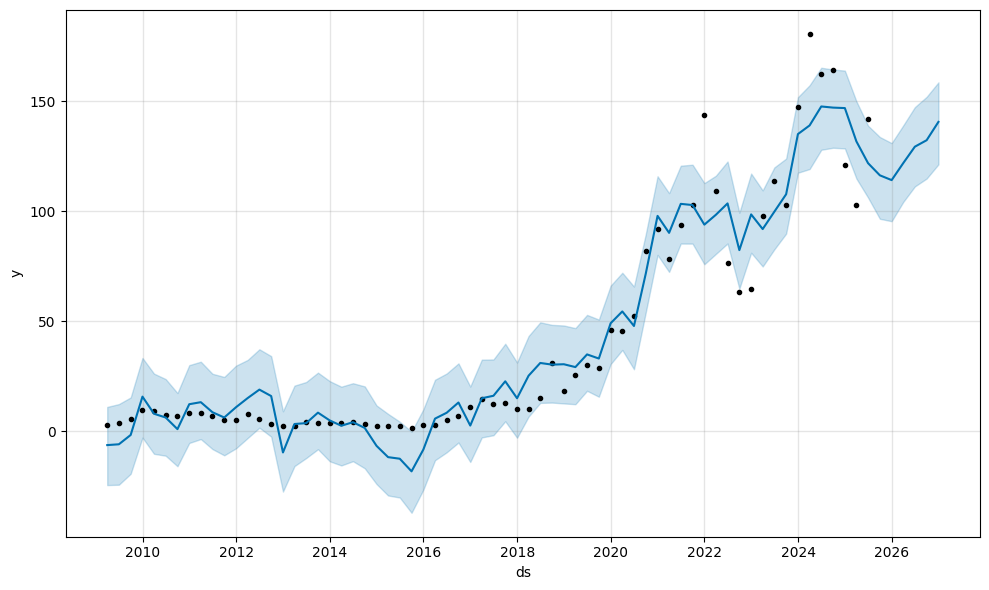

In [32]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()

In [33]:
correlations = data.corr()
correlations

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
ds,1.000000,0.837505,0.796292,0.469865,0.805993,0.743219,0.268059,0.734807
y,0.837505,1.000000,0.902378,0.608214,0.893314,0.817603,0.217541,0.713681
revenue_musd,0.796292,0.902378,1.000000,0.549763,0.964734,0.942874,0.211476,0.755382
net_income_musd,0.469865,0.608214,0.549763,1.000000,0.454296,0.346947,0.165499,0.182999
assets_liabilities_ratio,0.805993,0.893314,0.964734,0.454296,1.000000,0.975657,0.175420,0.810191
share_holder_equity_musd,0.743219,0.817603,0.942874,0.346947,0.975657,1.000000,0.137766,0.847239
gdp_growth,0.268059,0.217541,0.211476,0.165499,0.175420,0.137766,1.000000,0.138662
interest_rate,0.734807,0.713681,0.755382,0.182999,0.810191,0.847239,0.138662,1.000000


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_11614/89357559.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


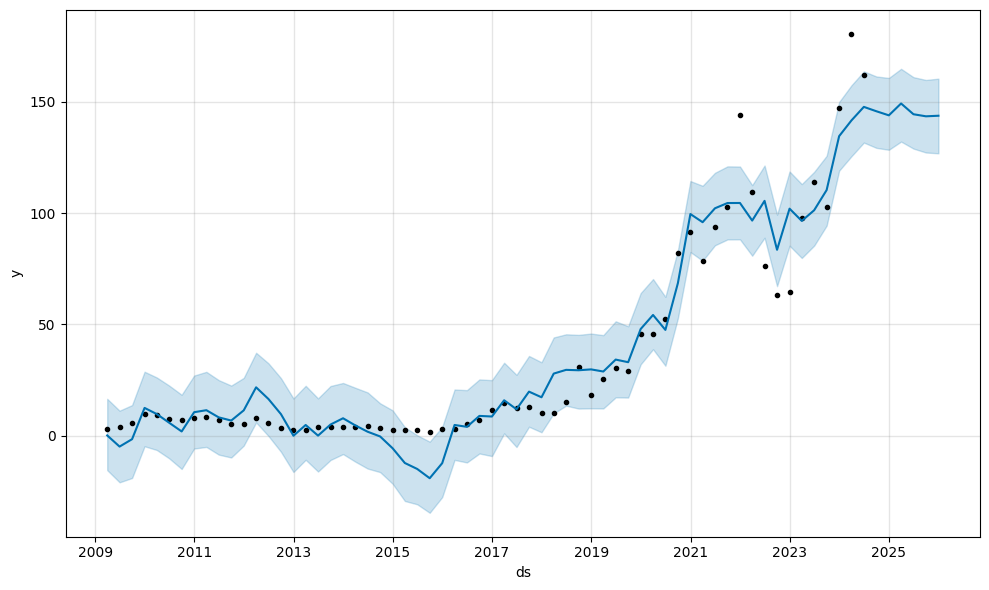

In [34]:
# 5) Plot the results for backtesting data

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()

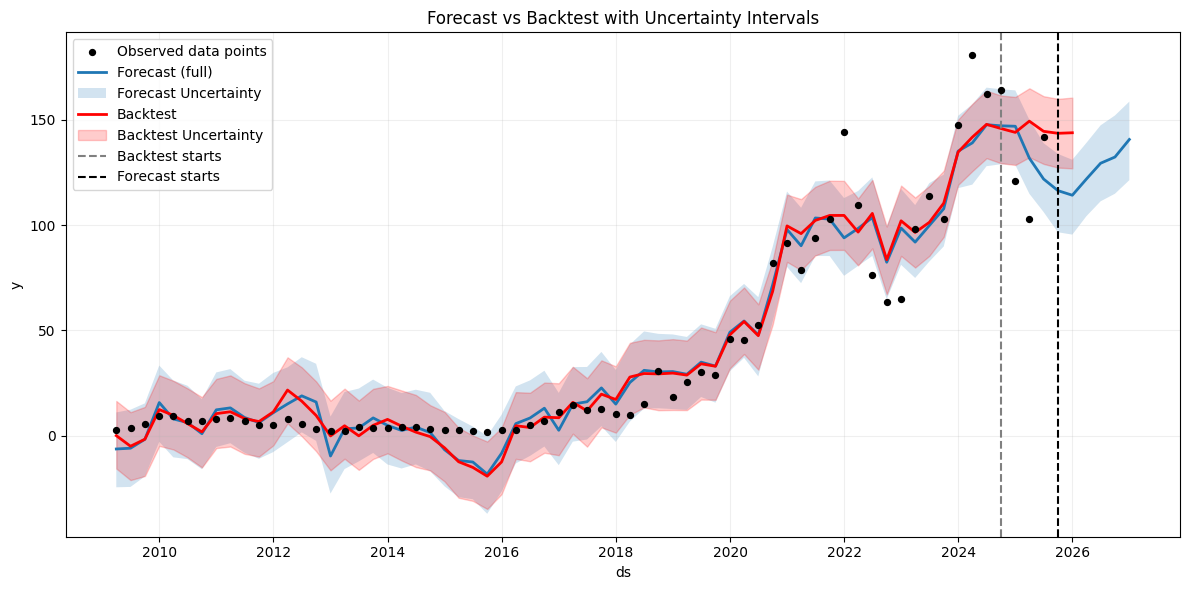

In [35]:
#6) Plot the results together

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'], 'ds'].min()   # ~2024-09-30
full_split = results.loc[results['is_future'], 'ds'].min()         # ~2025-09-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()